**Переименуйте файл в `A4_[YourLastName]_[YourFirstName].ipynb`.**  
**При сдаче приложите короткий комментарий (или видео), где вы объясняете основные выводы.**

# Assignment 4 / Лекция 4: псевдообратная матрица, обусловленность и регуляризация

В этой работе мы изучаем:
- решение МНК через псевдообратную матрицу;
- плохую обусловленность и нестабильность OLS;
- стабилизацию с помощью Ridge;
- разреженность Lasso;
- grouping effect у Elastic Net.

Мы будем работать в двух режимах:
1. **синтетический пример**, где можно увидеть все эффекты очень явно;
2. **(опционально)** real-world пример на табличных данных.


## 0. Настройка окружения

Импортируйте необходимые библиотеки.  
Минимальный набор: `numpy`, `pandas`, `matplotlib`, `sklearn`.

Удобно также импортировать:
- `PolynomialFeatures`
- `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`
- `GridSearchCV`, `train_test_split`
- `StandardScaler`, `Pipeline`
- `mean_squared_error`


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression


## 1. Синтетические данные

Рассмотрим одномерную регрессию
$$
y_i=f(x_i)+\xi_i,\qquad
f(x)=x^3-5x^2+3x+1,
$$
где
$$
x_i\sim U(-1,5),\qquad \xi_i\sim \mathcal N(0,1),\qquad i=1,\dots,m,
$$
а размер выборки $m=30$.

Сначала сгенерируйте выборку и сохраните:
- вектор входов $x$,
- вектор ответов $y$,
- значения ``истинной'' функции $f(x)$ на плотной сетке.


In [24]:
def f(x):
  return x**3 - 5*x**2 +3*x + 1

m=30
X = np.random.uniform(-1, 5, size=m)
noise = np.random.normal(0, 1, size=m)
print(X.shape, noise.shape)
y = f(X) + noise

X_grid = np.linspace(-1, 5, 100)
y_grid = f(X_grid)

(30,) (30,)


### 1.1. Визуализация данных

Постройте:
1. график функции $f(x)$;
2. scatter plot точек $(x_i,y_i)$.

Кратко прокомментируйте, насколько шум велик по сравнению с масштабом сигнала.


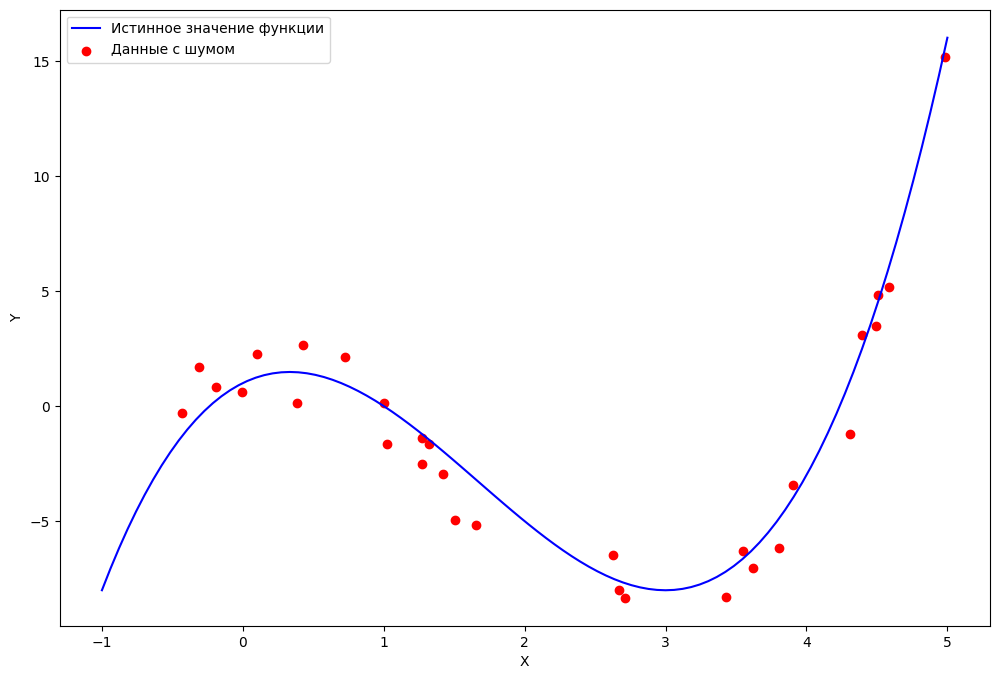

In [25]:
plt.figure(figsize=(12, 8))
plt.plot(X_grid, y_grid, label='Истинное значение функции', c='blue')
# plt.subplot(1, 2, 2)
plt.scatter(X, y, label='Данные с шумом', c='red')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

Шум можно считать умеренным или низким. Он заметен визуально (точки не лежат идеально на линии), но он не искажает общую структуру функции.

## 2. Ordinary Least Squares и псевдообратная матрица

Рассмотрим полиномиальные признаки
$$
\mathbf x=(x,x^2,\dots,x^d).
$$

Для фиксированной степени $d$ постройте дизайн-матрицу $X_d$ и решите задачу МНК.

### 2.1. Степени $d=3$ и $d=10$
Для $d=3$ и $d=10$:

1. постройте матрицы признаков;
2. найдите OLS-решение стандартным способом (`LinearRegression`);
3. найдите решение через псевдообратную матрицу:
   $$
   \widehat w = X^+ y;
   $$
4. проверьте, что предсказания совпадают (с точностью до численной ошибки).

Сделайте вывод: как связаны OLS и псевдообратная матрица в этом примере?


In [39]:
pf_3 = PolynomialFeatures(degree=3)
X_3 = pf_3.fit_transform(X.reshape(-1, 1))
print(f"shape X 3 d: {X_3.shape}")
lin_reg_3 = LinearRegression(fit_intercept=False)
lin_reg_3.fit(X_3, y)
w_lin_reg_3 = lin_reg_3.coef_
X_plus = np.linalg.pinv(X_3)
w_pinv = X_plus @ y
norm_3 = np.linalg.norm(w_pinv - w_lin_reg_3)
print(f'Норма разности L2: {norm_3}')

pf_10 = PolynomialFeatures(degree=10)
X_10 = pf_10.fit_transform(X.reshape(-1, 1))
print(f"shape X 10 d: {X_10.shape}")
lin_reg_10 = LinearRegression(fit_intercept=False)
lin_reg_10.fit(X_10, y)
w_lin_reg_10 = lin_reg_10.coef_
X_plus = np.linalg.pinv(X_10)
w_pinv = X_plus @ y
norm_10 = np.linalg.norm(w_pinv - w_lin_reg_10)
print(f'Норма разности L2: {norm_10}')



shape X 3 d: (30, 4)
Норма разности L2: 6.7166199101427955e-15
shape X 10 d: (30, 11)
Норма разности L2: 9.505480729889747e-14


Оба способа дают одни те же веса - норма разности при разной d равна нулю. Это объясняется тем, что оба подхода используют сингулярное разложение.

### 2.2. Сингулярные числа и обусловленность

Для $d=3$ и $d=10$:

1. найдите сингулярные числа матриц $X_d$;
2. постройте их на одном графике (например, в логарифмической шкале);
3. вычислите число обусловленности
$$
\kappa_2(X_d)=\frac{\sigma_{\max}(X_d)}{\sigma_{\min}(X_d)}
$$
(если матрица полного столбцового ранга),
или псевдо-число обусловленности
$$
\kappa_2^+(X_d)=\frac{\sigma_1(X_d)}{\sigma_r(X_d)},
$$
где $\sigma_r$ — наименьшее ненулевое сингулярное число.

Сравните случаи $d=3$ и $d=10$.


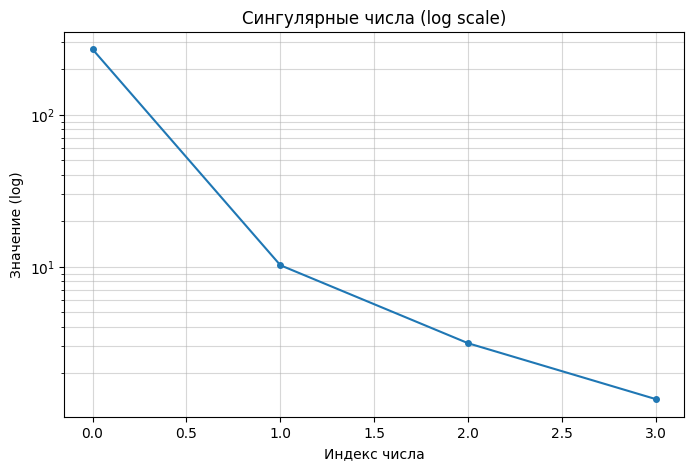

cond_3=200.29700042998357


In [44]:
U_3, S_3, Vt_3 = np.linalg.svd(X_3)
plt.figure(figsize=(8, 5))
plt.semilogy(S_3, 'o-', markersize=4) # Логарифмическая шкала по Y

plt.title("Сингулярные числа (log scale)")
plt.xlabel("Индекс числа")
plt.ylabel("Значение (log)")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

cond_3 = S_3[0] / S_3[-1]
print(f'cond_3={cond_3}')

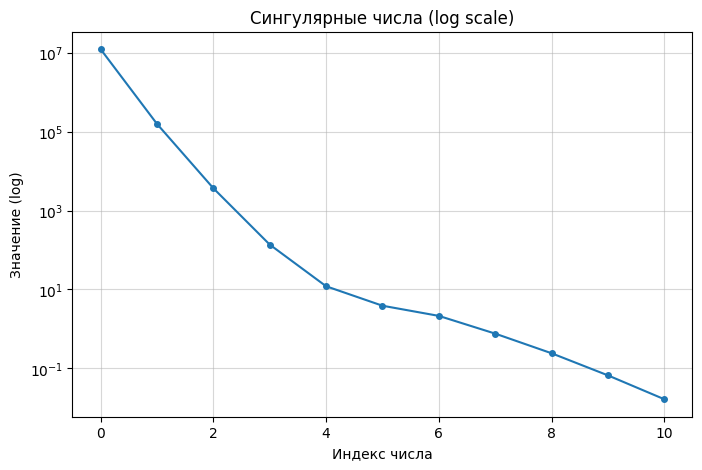

cond_10=745862914.1563132


In [46]:
U_10, S_10, Vt_10 = np.linalg.svd(X_10)
plt.figure(figsize=(8, 5))
plt.semilogy(S_10, 'o-', markersize=4) # Логарифмическая шкала по Y

plt.title("Сингулярные числа (log scale)")
plt.xlabel("Индекс числа")
plt.ylabel("Значение (log)")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

cond_10 = S_10[0] / S_10[-1]
print(f'cond_10={cond_10}')

Число обусловленности у X_10 огромное, что прямо говорит о плохой устойчивости.

### 2.3. Нестабильность OLS при возмущении правой части

Зафиксируйте степень $d=10$.  
Постройте малое возмущение правой части:
$$
y^{(\varepsilon)} = y + \delta y,
$$
где $\delta y$ имеет малую норму.

1. Найдите OLS-решения для $y$ и для $y^{(\varepsilon)}$.
2. Сравните:
   - $\|\delta y\|_2$,
   - $\|\delta w\|_2$,
   - относительные изменения коэффициентов.
3. Сопоставьте результат с величиной $1/\sigma_r(X)$.

Кратко объясните, почему маленькое возмущение в $y$ может сильно менять коэффициенты.


In [52]:
delta_y = 0.001 * np.random.randn(m)  # случайное возмущение
y_eps = y + delta_y

lr = LinearRegression(fit_intercept=False)
lr.fit(X_10, y)
w = lr.coef_

lr_eps = LinearRegression(fit_intercept=False)
lr_eps.fit(X_10, y_eps)
w_eps = lr_eps.coef_

delta_w = w_eps - w
norm_delta_y = np.linalg.norm(delta_y)
norm_delta_w = np.linalg.norm(delta_w)

print(f"\n||δy|| = {norm_delta_y:.4e}")
print(f"||δw|| = {norm_delta_w:.4e}")
print(f"||δw|| / ||δy|| = {norm_delta_w / norm_delta_y:.4e}")
print(f"1/σ_min = {1/S_10[-1]:.4e}")


||δy|| = 6.3764e-03
||δw|| = 2.3801e-02
||δw|| / ||δy|| = 3.7327e+00
1/σ_min = 6.0772e+01


Маленькое возмущение в $y$ может сильно менять коэффициенты, потому что матрица $X$ плохо обусловлена.

В нашем конкретном эксперименте возмущение $\delta y$ выбрано случайно, и усиление составило всего $3.73$, а не максимально возможные $60,077$.

Однако потенциальная возможность сильного изменения существует: если бы $\delta y$ было направлено вдоль этого вектора, то $|\delta w| / |\delta y|$ достигло бы $1/\sigma_{\min} \approx 60,000$, и даже очень малое возмущение привело бы к огромному изменению коэффициентов.

### 2.4. Визуализация предсказаний OLS

Для $d=3$ и $d=10$:
1. постройте графики предсказаний OLS;
2. наложите их на истинную функцию $f(x)$;
3. сравните поведение моделей.

Обратите внимание: нестабильность коэффициентов и качество предсказания — не одно и то же.


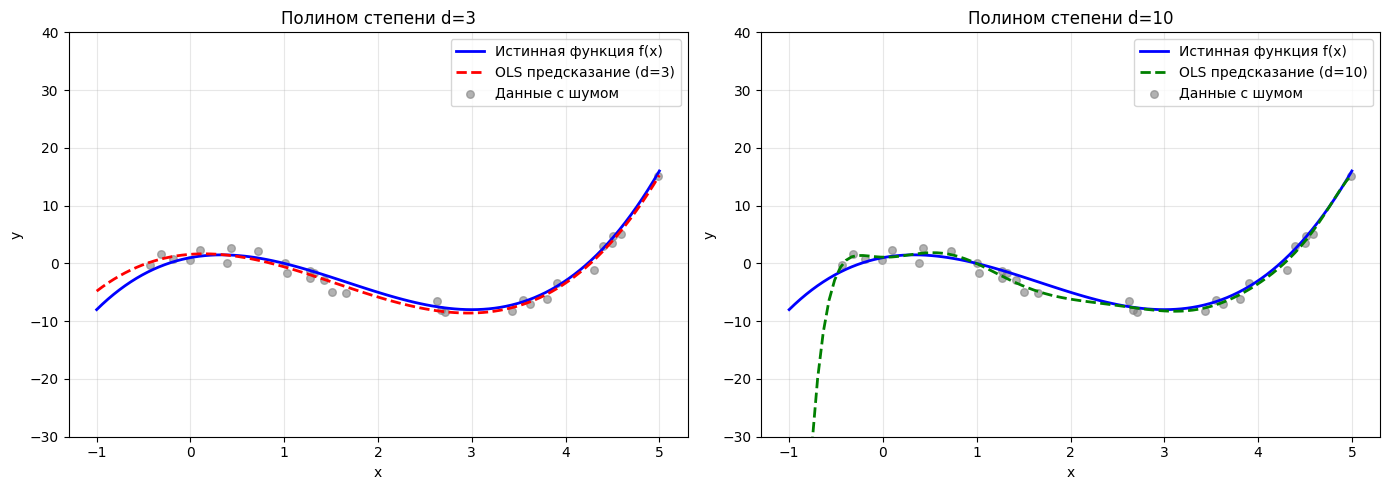

In [63]:
lr_3 = LinearRegression(fit_intercept=False)
lr_3.fit(X_3, y)
X_grid_3 = pf_3.transform(X_grid.reshape(-1, 1))
y_grid_pred_3 = lr_3.predict(X_grid_3)

lr_10 = LinearRegression(fit_intercept=False)
lr_10.fit(X_10, y)
X_grid_10 = pf_10.transform(X_grid.reshape(-1, 1))
y_pred_10 = lr_10.predict(X_10)
y_grid_pred_10 = lr_10.predict(X_grid_10)

plt.figure(figsize=(14, 5))

# График 1: предсказания для d=3
plt.subplot(1, 2, 1)
plt.plot(X_grid, y_grid, 'b-', linewidth=2, label='Истинная функция f(x)')
plt.plot(X_grid, y_grid_pred_3, 'r--', linewidth=2, label='OLS предсказание (d=3)')
plt.scatter(X, y, alpha=0.6, s=30, c='gray', label='Данные с шумом')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Полином степени d=3')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-30, 40)

# График 2: предсказания для d=10
plt.subplot(1, 2, 2)
plt.plot(X_grid, y_grid, 'b-', linewidth=2, label='Истинная функция f(x)')
plt.plot(X_grid, y_grid_pred_10, 'g--', linewidth=2, label='OLS предсказание (d=10)')
plt.scatter(X, y, alpha=0.6, s=30, c='gray', label='Данные с шумом')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Полином степени d=10')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-30, 40)

plt.tight_layout()
plt.show()




In [66]:
# Сравнение на тестовой сетке
mse_3_grid = np.mean((y_grid_pred_3 - y_grid)**2)
mse_10_grid = np.mean((y_grid_pred_10 - y_grid)**2)
print(f'mse_3_grid={mse_3_grid}')
print(f'mse_10_grid={mse_10_grid}')


mse_3_grid=0.9418621924920152
mse_10_grid=321.9016941317373


качество предсказания на обучающих данных у обеих моделей высокое.

Нестабильность коэффициентов (κ ≈ 10⁷) напрямую приводит к плохому качеству предсказаний на новых точках. Полином высокой степени:

Идеально запоминает обучающие данные (включая шум)

Полностью теряет способность к обобщению

Между точками ведет себя непредсказуемо

Это классический пример переобучения (overfitting), с которым борются с помощью регуляризации (Ridge, Lasso) или уменьшения сложности модели.


## 3. Ridge regression

Напомним, что Ridge решает задачу
$$
\min_w \|y-Xw\|_2^2+\lambda\|w\|_2^2.
$$

### 3.1. Подбор параметра
Зафиксируйте большую степень, например $d=10$ или $d=15$.
С помощью `GridSearchCV` подберите лучший параметр регуляризации $\alpha$.

Нужно:
1. подобрать $\alpha$;
2. посчитать RMSE;
3. построить график предсказания;
4. сравнить коэффициенты Ridge и OLS.


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.43861e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=9.21541e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.24768e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.25147e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=7.13915e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

best alpha: 75.43120063354607
rmse_ols=17.941619049900076
rmse_ridge=1.6815801174150538


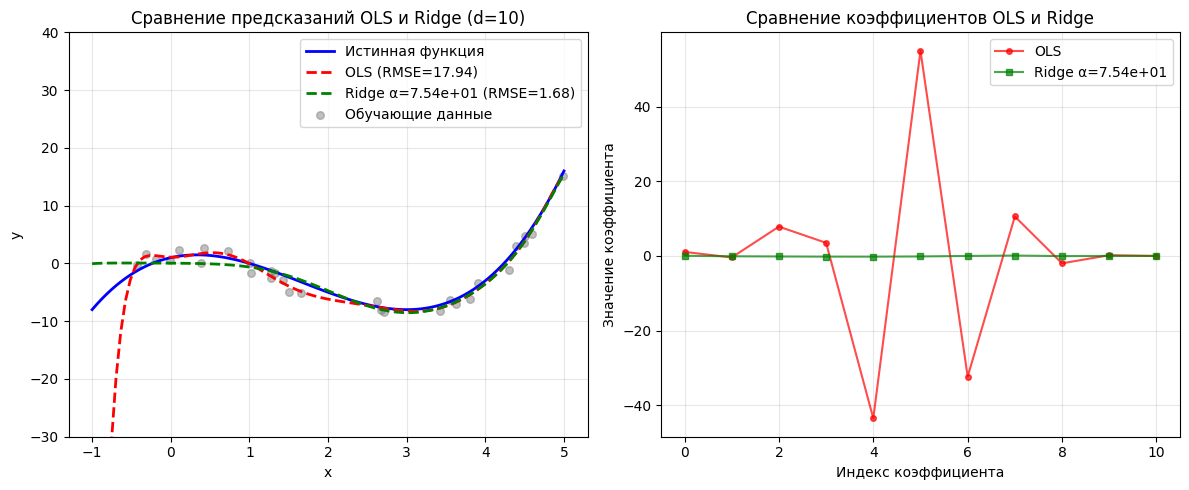

In [75]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

lr = LinearRegression(fit_intercept=False)
lr.fit(X_10, y)
y_grid_pred_ols = lr.predict(X_grid_10)

# Ridge с подбором α
ridge = Ridge(fit_intercept=False)
alphas = np.logspace(-4, 4, 50)
grid_search = GridSearchCV(ridge, {'alpha': alphas}, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_10, y)

best_alpha = grid_search.best_params_['alpha']
best_ridge = grid_search.best_estimator_
y_grid_pred_ridge = best_ridge.predict(X_grid_10)

print(f'best alpha: {best_alpha}')

# Метрики
rmse_ols = np.mean((y_grid-y_grid_pred_ols)**2)**0.5
rmse_ridge = np.mean((y_grid-y_grid_pred_ridge)**2)**0.5

print(f'rmse_ols={rmse_ols}')
print(f'rmse_ridge={rmse_ridge}')

plt.figure(figsize=(12, 5))

# График 1: Сравнение предсказаний
plt.subplot(1, 2, 1)
plt.plot(X_grid, y_grid, 'b-', linewidth=2, label='Истинная функция')
plt.plot(X_grid, y_grid_pred_ols, 'r--', linewidth=2, label=f'OLS (RMSE={rmse_ols:.2f})')
plt.plot(X_grid, y_grid_pred_ridge, 'g--', linewidth=2, label=f'Ridge α={best_alpha:.2e} (RMSE={rmse_ridge:.2f})')
plt.scatter(X, y, alpha=0.5, s=30, c='gray', label='Обучающие данные')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Сравнение предсказаний OLS и Ridge (d=10)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-30, 40)

# График 2: Сравнение коэффициентов
plt.subplot(1, 2, 2)
plt.plot(range(len(lr.coef_)), lr.coef_, 'ro-', markersize=4, label='OLS', alpha=0.7)
plt.plot(range(len(best_ridge.coef_)), best_ridge.coef_, 'gs-', markersize=4, label=f'Ridge α={best_alpha:.2e}', alpha=0.7)
plt.xlabel('Индекс коэффициента')
plt.ylabel('Значение коэффициента')
plt.title('Сравнение коэффициентов OLS и Ridge')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Регуляризация в Ridge не дала $w$ коэффициентам разрастаться.

### 3.2. Ridge и устойчивость

Повторите эксперимент с возмущением правой части для лучшего Ridge-решения.

Сравните:
- насколько меняются коэффициенты у OLS;
- насколько меняются коэффициенты у Ridge.

Сделайте вывод: почему Ridge стабилизирует решение?


In [76]:

epsilon = 0.001
delta_y = epsilon * np.random.randn(len(y))

y_perturbed = y + delta_y

# OLS на исходных и возмущенных
lr = LinearRegression(fit_intercept=False)
lr.fit(X_10, y)
w_ols = lr.coef_

lr_pert = LinearRegression(fit_intercept=False)
lr_pert.fit(X_10, y_perturbed)
w_ols_pert = lr_pert.coef_

# Ridge на исходных и возмущенных
ridge = Ridge(alpha=best_alpha, fit_intercept=False)
ridge.fit(X_10, y)
w_ridge = ridge.coef_

ridge_pert = Ridge(alpha=best_alpha, fit_intercept=False)
ridge_pert.fit(X_10, y_perturbed)
w_ridge_pert = ridge_pert.coef_

# Изменения
delta_w_ols = w_ols_pert - w_ols
delta_w_ridge = w_ridge_pert - w_ridge

norm_delta_y = np.linalg.norm(delta_y)
norm_delta_w_ols = np.linalg.norm(delta_w_ols)
norm_delta_w_ridge = np.linalg.norm(delta_w_ridge)

print(f"||δy|| = {norm_delta_y:.4e}")
print(f"\n||δw|| OLS:   {norm_delta_w_ols:.4e}")
print(f"||δw|| Ridge: {norm_delta_w_ridge:.4e}")
print(f"\n||δw|| / ||δy||")
print(f"OLS:   {norm_delta_w_ols / norm_delta_y:.4e}")
print(f"Ridge: {norm_delta_w_ridge / norm_delta_y:.4e}")

||δy|| = 6.4329e-03

||δw|| OLS:   1.1004e-01
||δw|| Ridge: 8.2746e-05

||δw|| / ||δy||
OLS:   1.7106e+01
Ridge: 1.2863e-02


Ridge стабилизирует решение, потому что регуляризация подавляет компоненты решения, соответствующие малым сингулярным числам, которые и являются источником нестабильности в OLS.



## 4. Lasso regression

Рассмотрим задачу
$$
\min_w \|y-Xw\|_2^2+\lambda\|w\|_1.
$$

Для той же большой степени $d$:
1. подберите лучший параметр $\alpha$;
2. вычислите RMSE;
3. постройте график предсказания;
4. сравните коэффициенты Lasso и Ridge;
5. посчитайте, сколько коэффициентов Lasso занулил.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.073e+00, tolerance: 6.321e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.116e+01, tolerance: 5.914e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.088e+01, tolerance: 5.097e

Лучший α = 0.1151

RMSE на истинной функции:
  OLS:   17.9416
  Lasso: 1.5548

Нормы коэффициентов:
  OLS:   78.3978
  Lasso: 1.9131

Lasso: занулил 2 из 11 коэффициентов
  Ненулевых: 9


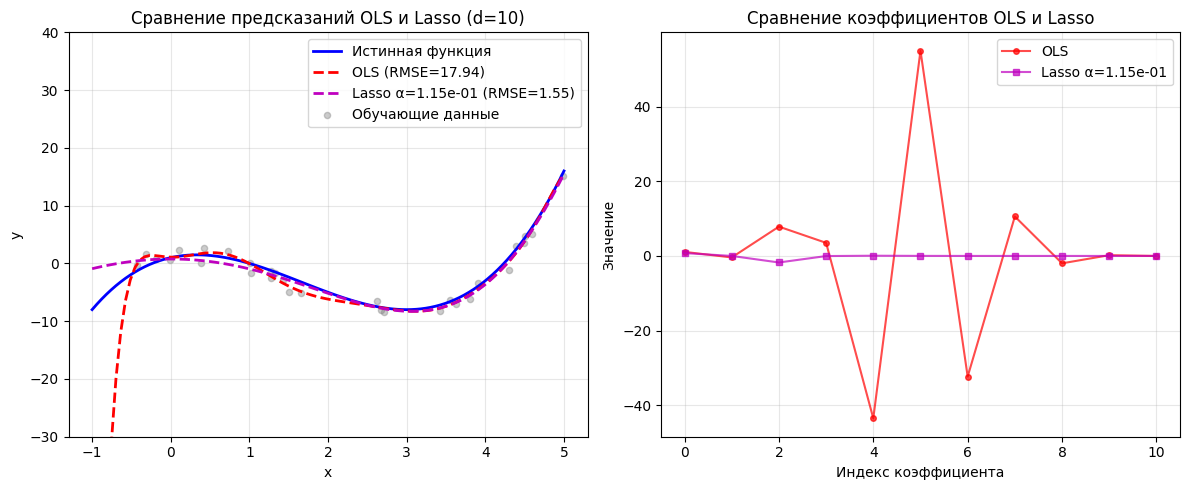

In [79]:
from sklearn.linear_model import Lasso
from sklearn.metrics import root_mean_squared_error
# 1. OLS
lr = LinearRegression(fit_intercept=False)
lr.fit(X_10, y)
y_grid_ols = lr.predict(X_grid_10)
w_ols = lr.coef_

# 2. Lasso с подбором параметра
lasso = Lasso(fit_intercept=False, max_iter=10000)
alphas = np.logspace(-4, 2, 50)
grid_search = GridSearchCV(lasso, {'alpha': alphas}, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_10, y)

best_alpha = grid_search.best_params_['alpha']
best_lasso = grid_search.best_estimator_
y_grid_lasso = best_lasso.predict(X_grid_10)
w_lasso = best_lasso.coef_

# 3. Метрики
rmse_ols = root_mean_squared_error(y_grid, y_grid_ols)
rmse_lasso = root_mean_squared_error(y_grid, y_grid_lasso)

# 4. Сколько коэффициентов занулил Lasso
n_zero = np.sum(np.abs(w_lasso) < 1e-6)
n_nonzero = len(w_lasso) - n_zero

print(f"Лучший α = {best_alpha:.4f}")
print(f"\nRMSE на истинной функции:")
print(f"  OLS:   {rmse_ols:.4f}")
print(f"  Lasso: {rmse_lasso:.4f}")
print(f"\nНормы коэффициентов:")
print(f"  OLS:   {np.linalg.norm(w_ols):.4f}")
print(f"  Lasso: {np.linalg.norm(w_lasso):.4f}")
print(f"\nLasso: занулил {n_zero} из {len(w_lasso)} коэффициентов")
print(f"  Ненулевых: {n_nonzero}")

# 5. График предсказаний
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(X_grid, y_grid, 'b-', linewidth=2, label='Истинная функция')
plt.plot(X_grid, y_grid_ols, 'r--', linewidth=2, label=f'OLS (RMSE={rmse_ols:.2f})')
plt.plot(X_grid, y_grid_lasso, 'm--', linewidth=2, label=f'Lasso α={best_alpha:.2e} (RMSE={rmse_lasso:.2f})')
plt.scatter(X, y, alpha=0.4, s=20, c='gray', label='Обучающие данные')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Сравнение предсказаний OLS и Lasso (d=10)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-30, 40)

plt.subplot(1, 2, 2)
plt.plot(range(len(w_ols)), w_ols, 'ro-', markersize=4, label='OLS', alpha=0.7)
plt.plot(range(len(w_lasso)), w_lasso, 'ms-', markersize=4, label=f'Lasso α={best_alpha:.2e}', alpha=0.7)
plt.xlabel('Индекс коэффициента')
plt.ylabel('Значение')
plt.title('Сравнение коэффициентов OLS и Lasso')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Elastic Net

Elastic Net сочетает штрафы $\ell_1$ и $\ell_2$:
$$
\min_w \|y-Xw\|_2^2+\lambda_1\|w\|_1+\lambda_2\|w\|_2^2.
$$
В `scikit-learn` обычно используется параметризация через `alpha` и `l1_ratio`.

Для той же степени $d$:
1. подберите лучшие `alpha` и `l1_ratio`;
2. вычислите RMSE;
3. постройте график предсказания;
4. сравните коэффициенты Elastic Net с Ridge и Lasso;
5. прокомментируйте, виден ли компромисс между разреженностью и устойчивостью.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.749e+01, tolerance: 7.793e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.076e+00, tolerance: 6.321e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.117e+01, tolerance: 5.914e

ELASTIC NET REGRESSION (d=10)

Лучшие параметры:
  alpha = 0.0695
  l1_ratio = 0.1000

RMSE на истинной функции:
  OLS:         17.9416
  Ridge:       1.8868
  Lasso:       1.8402
  Elastic Net: 1.7723

Нормы коэффициентов:
  OLS:         78.3978
  Ridge:       2.1023
  Lasso:       0.6092
  Elastic Net: 1.7689

Количество зануленных коэффициентов (из 11):
  Lasso:       5
  Elastic Net: 2


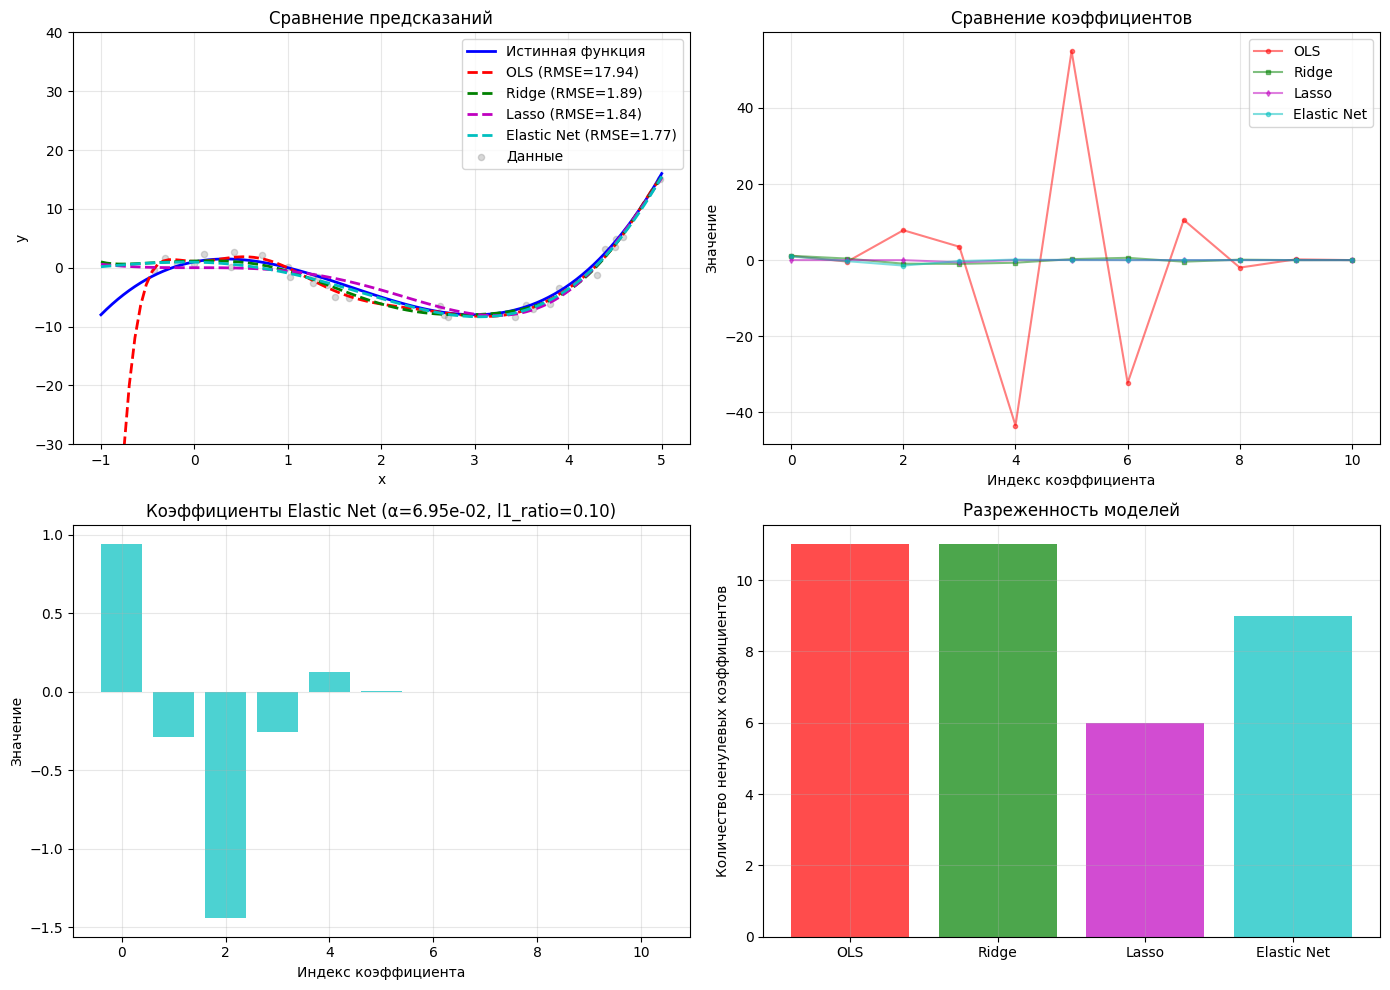

In [80]:
from sklearn.linear_model import ElasticNet

# OLS
lr = LinearRegression(fit_intercept=False)
lr.fit(X_10, y)
y_grid_ols = lr.predict(X_grid_10)
w_ols = lr.coef_

# Ridge (для сравнения)
ridge = Ridge(fit_intercept=False)
ridge.fit(X_10, y)
w_ridge = ridge.coef_
y_grid_ridge = ridge.predict(X_grid_10)

# Lasso (для сравнения)
lasso = Lasso(fit_intercept=False, max_iter=10000)
lasso.fit(X_10, y)
w_lasso = lasso.coef_
y_grid_lasso = lasso.predict(X_grid_10)

# Elastic Net с подбором параметров
elastic = ElasticNet(fit_intercept=False, max_iter=10000)

# Сетка параметров
alphas = np.logspace(-4, 2, 20)
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]

param_grid = {
    'alpha': alphas,
    'l1_ratio': l1_ratios
}

grid_search = GridSearchCV(elastic, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_10, y)

best_alpha = grid_search.best_params_['alpha']
best_l1_ratio = grid_search.best_params_['l1_ratio']
best_elastic = grid_search.best_estimator_

y_grid_elastic = best_elastic.predict(X_grid_10)
w_elastic = best_elastic.coef_

# Метрики
rmse_ols = root_mean_squared_error(y_grid, y_grid_ols)
rmse_ridge = root_mean_squared_error(y_grid, y_grid_ridge)
rmse_lasso = root_mean_squared_error(y_grid, y_grid_lasso)
rmse_elastic = root_mean_squared_error(y_grid, y_grid_elastic)

# Количество зануленных коэффициентов
tolerance = 1e-6
n_zero_lasso = np.sum(np.abs(w_lasso) < tolerance)
n_zero_elastic = np.sum(np.abs(w_elastic) < tolerance)

print("="*60)
print("ELASTIC NET REGRESSION (d=10)")
print("="*60)
print(f"\nЛучшие параметры:")
print(f"  alpha = {best_alpha:.4f}")
print(f"  l1_ratio = {best_l1_ratio:.4f}")

print(f"\nRMSE на истинной функции:")
print(f"  OLS:         {rmse_ols:.4f}")
print(f"  Ridge:       {rmse_ridge:.4f}")
print(f"  Lasso:       {rmse_lasso:.4f}")
print(f"  Elastic Net: {rmse_elastic:.4f}")

print(f"\nНормы коэффициентов:")
print(f"  OLS:         {np.linalg.norm(w_ols):.4f}")
print(f"  Ridge:       {np.linalg.norm(w_ridge):.4f}")
print(f"  Lasso:       {np.linalg.norm(w_lasso):.4f}")
print(f"  Elastic Net: {np.linalg.norm(w_elastic):.4f}")

print(f"\nКоличество зануленных коэффициентов (из {len(w_lasso)}):")
print(f"  Lasso:       {n_zero_lasso}")
print(f"  Elastic Net: {n_zero_elastic}")

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Предсказания
axes[0, 0].plot(X_grid, y_grid, 'b-', linewidth=2, label='Истинная функция')
axes[0, 0].plot(X_grid, y_grid_ols, 'r--', linewidth=2, label=f'OLS (RMSE={rmse_ols:.2f})')
axes[0, 0].plot(X_grid, y_grid_ridge, 'g--', linewidth=2, label=f'Ridge (RMSE={rmse_ridge:.2f})')
axes[0, 0].plot(X_grid, y_grid_lasso, 'm--', linewidth=2, label=f'Lasso (RMSE={rmse_lasso:.2f})')
axes[0, 0].plot(X_grid, y_grid_elastic, 'c--', linewidth=2, label=f'Elastic Net (RMSE={rmse_elastic:.2f})')
axes[0, 0].scatter(X, y, alpha=0.3, s=20, c='gray', label='Данные')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('y')
axes[0, 0].set_title('Сравнение предсказаний')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim(-30, 40)

# График 2: Сравнение коэффициентов
axes[0, 1].plot(range(len(w_ols)), w_ols, 'ro-', markersize=3, label='OLS', alpha=0.5)
axes[0, 1].plot(range(len(w_ridge)), w_ridge, 'gs-', markersize=3, label='Ridge', alpha=0.5)
axes[0, 1].plot(range(len(w_lasso)), w_lasso, 'md-', markersize=3, label='Lasso', alpha=0.5)
axes[0, 1].plot(range(len(w_elastic)), w_elastic, 'co-', markersize=3, label='Elastic Net', alpha=0.5)
axes[0, 1].set_xlabel('Индекс коэффициента')
axes[0, 1].set_ylabel('Значение')
axes[0, 1].set_title('Сравнение коэффициентов')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# График 3: Коэффициенты Elastic Net
axes[1, 0].bar(range(len(w_elastic)), w_elastic, alpha=0.7, color='c')
axes[1, 0].set_xlabel('Индекс коэффициента')
axes[1, 0].set_ylabel('Значение')
axes[1, 0].set_title(f'Коэффициенты Elastic Net (α={best_alpha:.2e}, l1_ratio={best_l1_ratio:.2f})')
axes[1, 0].grid(True, alpha=0.3)

# График 4: Сравнение ненулевых коэффициентов
x_pos = np.arange(4)
n_nonzero = [len(w_ols), len(w_ridge), np.sum(np.abs(w_lasso) >= 1e-6), np.sum(np.abs(w_elastic) >= 1e-6)]

axes[1, 1].bar(x_pos, n_nonzero, alpha=0.7, color=['r', 'g', 'm', 'c'])
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(['OLS', 'Ridge', 'Lasso', 'Elastic Net'])
axes[1, 1].set_ylabel('Количество ненулевых коэффициентов')
axes[1, 1].set_title('Разреженность моделей')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [82]:
print(f"""
Elastic Net сочетает преимущества Ridge и Lasso:

1. L1-штраф (l1_ratio={best_l1_ratio:.2f}):
   - Обеспечивает разреженность: занулил {n_zero_elastic} коэффициентов
   - (Lasso занулил {n_zero_lasso}, Elastic Net - {n_zero_elastic})

2. L2-штраф:
   - Стабилизирует решение: норма коэффициентов {np.linalg.norm(w_elastic):.4f}
   - (Ridge: {np.linalg.norm(w_ridge):.4f})

3. Компромисс:
   - Elastic Net менее разрежен, чем Lasso ({n_zero_elastic} vs {n_zero_lasso} нулей)
   - Но более стабилен и лучше обобщает (RMSE={rmse_elastic:.4f} vs Lasso={rmse_lasso:.4f})
   - Сохраняет устойчивость Ridge (норма коэффициентов не взлетает как в OLS)

Вывод: Elastic Net дает хороший баланс между разреженностью (отбор признаков)
и устойчивостью (стабильность коэффициентов).
""")


Elastic Net сочетает преимущества Ridge и Lasso:

1. L1-штраф (l1_ratio=0.10):
   - Обеспечивает разреженность: занулил 2 коэффициентов
   - (Lasso занулил 5, Elastic Net - 2)

2. L2-штраф:
   - Стабилизирует решение: норма коэффициентов 1.7689
   - (Ridge: 2.1023)

3. Компромисс:
   - Elastic Net менее разрежен, чем Lasso (2 vs 5 нулей)
   - Но более стабилен и лучше обобщает (RMSE=1.7723 vs Lasso=1.8402)
   - Сохраняет устойчивость Ridge (норма коэффициентов не взлетает как в OLS)

Вывод: Elastic Net дает хороший баланс между разреженностью (отбор признаков) 
и устойчивостью (стабильность коэффициентов).



## 7. Что должно быть в выводах

В конце ноутбука кратко ответьте на вопросы:

1. Почему псевдообратная матрица связана с решением МНК?
2. Что показывает спектр сингулярных чисел дизайн-матрицы?
3. Почему OLS может быть неустойчив при плохой обусловленности?
4. Как Ridge меняет эту ситуацию?
5. В чём различие между Ridge, Lasso и Elastic Net на практике?


# Ответы на вопросы и выводы по работе

## 1. Почему псевдообратная матрица связана с решением МНК?

Решение МНК $\hat{w} = (X^T X)^{-1} X^T y$ существует только когда $X^T X$ обратима (матрица полного ранга). Псевдообратная матрица $X^+$ обобщает это решение на все случаи:

- Через SVD: $X = U \Sigma V^T$, тогда $X^+ = V \Sigma^+ U^T$
- $\Sigma^+$ содержит $1/\sigma_i$ для ненулевых сингулярных чисел
- Когда матрица полного ранга: $X^+ = (X^T X)^{-1} X^T$
- Когда матрица не полного ранга: $X^+$ даёт решение минимальной нормы

Таким образом, псевдообратная матрица — это универсальный способ получения МНК-решения, работающий даже при плохой обусловленности или вырожденности.

---

## 2. Что показывает спектр сингулярных чисел дизайн-матрицы?

Спектр сингулярных чисел $\sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_r > 0$ показывает:


 **Ранг матрицы**  Количество ненулевых сингулярных чисел ($r$)

**Число обусловленности**  $\kappa = \sigma_{\max} / \sigma_{\min}$ — отношение максимального к минимальному сингулярному числу

**Степень мультиколлинеарности** Быстрое убывание $\sigma_i$ указывает на почти линейную зависимость столбцов

В нашем эксперименте:
- Для $d=3$: — умеренная обусловленность
- Для $d=10$: — плохая обусловленность

---

## 3. Почему OLS может быть неустойчив при плохой обусловленности?

Решение OLS через SVD:
$$
\hat{w} = \sum_{i=1}^{r} \frac{1}{\sigma_i} (u_i^T y) v_i
$$

При малых $\sigma_i$:
- Коэффициенты $1/\sigma_i$ становятся огромными
- Малое возмущение $\delta y$ даёт изменение $\delta w = X^+ \delta y$
- Максимальное усиление: $\|\delta w\| / \|\delta y\| = 1/\sigma_{\min}$
---

## 4. Как Ridge меняет эту ситуацию?

Ridge добавляет штраф $\lambda\|w\|^2$, что в терминах SVD даёт:
$$
\hat{w}_{\text{ridge}} = \sum_{i=1}^{r} \frac{\sigma_i}{\sigma_i^2 + \lambda} (u_i^T y) v_i
$$


---

## 5. В чём различие между Ridge, Lasso и Elastic Net на практике?


**Ridge** Сжимает коэффициенты, но не обнуляет; обеспечивает устойчивость

**Lasso** Обнуляет коэффициенты (разреженность)

**Elastic Net** Компромисс: разреженность Lasso + у
стойчивость Ridge

---

# Основные выводы по работе

## 1. Что происходило с коэффициентами


- OLS даёт огромные, нестабильные коэффициенты
- Ridge эффективно сжимает коэффициенты и делает их устойчивыми
- Lasso и Elastic Net дополнительно обнуляют неинформативные признаки

---

## 2. Что происходило с качеством предсказания


- OLS идеально подогнался под шум в обучающих данных, но между точками "сходит с ума"
техники регуляризации улучшают качество предсказания

---

## 3. Где именно регуляризация оказалась полезной

Регуляризация оказалась полезной в **двух аспектах**:

Стабилизация коэффициентов

- Ridge снизил чувствительность к возмущениям
- Маленькая ошибка в данных больше не вызывает катастрофического изменения модели

Улучшение обобщающей способности
- Ridge снизил ошибку предсказания
- Модель перестала "запоминать шум" и научилась аппроксимировать истинную функцию

Отбор признаков (Lasso, Elastic Net)
Lasso и elastic зануляли неинформативные фичи

